In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving superstore_final_dataset (1).csv to superstore_final_dataset (1) (1).csv


In [ ]:
import os

print(os.listdir())


['.config', 'superstore_final_dataset (1).csv', 'archive (1).zip', 'superstore_final_dataset (1) (1).csv', 'sample_data']


In [ ]:
import pandas as pd

df = pd.read_csv("superstore_final_dataset.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'superstore_final_dataset.csv'

In [ ]:
import os
print(os.listdir())

['.config', 'superstore_final_dataset (1).csv', 'archive (1).zip', 'superstore_final_dataset (1) (1).csv', 'sample_data']


In [ ]:
import pandas as pd

df = pd.read_csv("superstore_final_dataset (1).csv")

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xa0 in position 2786: invalid start byte

In [ ]:
import pandas as pd

df = pd.read_csv("superstore_final_dataset (1).csv", encoding="latin1")

In [ ]:
df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row_ID         9800 non-null   int64  
 1   Order_ID       9800 non-null   object 
 2   Order_Date     9800 non-null   object 
 3   Ship_Date      9800 non-null   object 
 4   Ship_Mode      9800 non-null   object 
 5   Customer_ID    9800 non-null   object 
 6   Customer_Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal_Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product_ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub_Category   9800 non-null   object 
 16  Product_Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [ ]:
df.isnull().sum()

,0
Row_ID,0
Order_ID,0
Order_Date,0
Ship_Date,0
Ship_Mode,0
Customer_ID,0
Customer_Name,0
Segment,0
Country,0
City,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.dtypes

,0
Row_ID,int64
Order_ID,object
Order_Date,object
Ship_Date,object
Ship_Mode,object
Customer_ID,object
Customer_Name,object
Segment,object
Country,object
City,object


In [ ]:
df.describe()

,Row_ID,Postal_Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [ ]:
print(df.columns)

Index(['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
       'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State',
       'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category',
       'Product_Name', 'Sales'],
      dtype='object')


In [ ]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

ValueError: time data "15/04/2018" doesn't match format "%m/%d/%Y", at position 4. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [ ]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True)

In [ ]:
df['Order_Date'].head()

,Order_Date
0,2017-11-08
1,2017-11-08
2,2017-06-12
3,2016-10-11
4,2016-10-11


In [ ]:
total_revenue = df['Sales'].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 2261536.7827000003


In [ ]:
average_order_value = df.groupby('Order_ID')['Sales'].sum().mean()
print("Average Order Value:", round(average_order_value, 2))

Average Order Value: 459.48


In [ ]:
df['Year_Month'] = df['Order_Date'].dt.to_period('M')

In [ ]:
monthly_sales = df.groupby('Year_Month')['Sales'].sum()

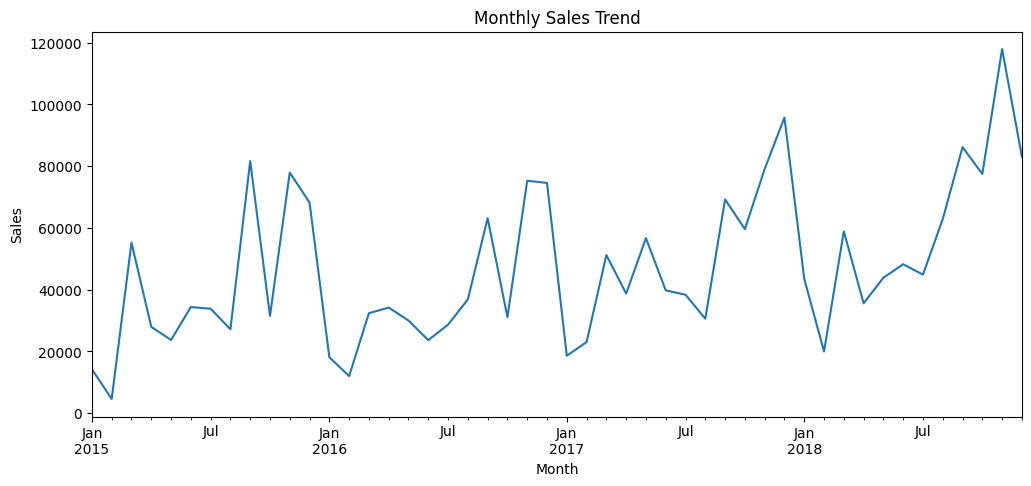

In [ ]:
plt.figure(figsize=(12,5))

monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()

In [ ]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

print(region_sales)

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64


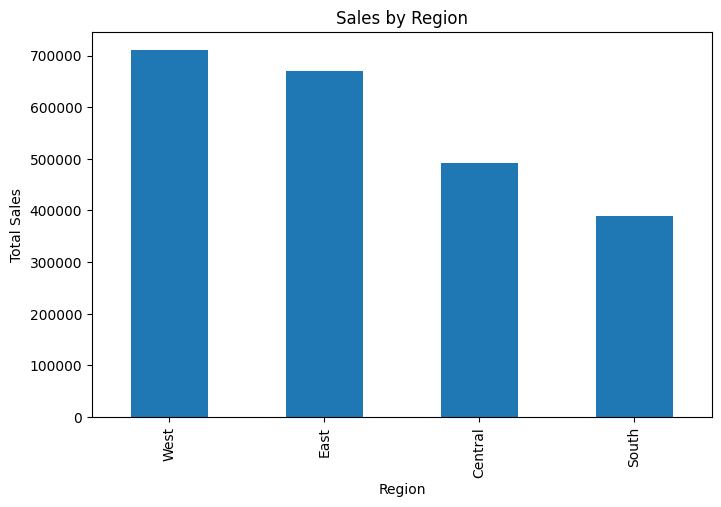

In [ ]:
plt.figure(figsize=(8,5))

region_sales.plot(kind='bar')

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.show()

In [ ]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

print(category_sales)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


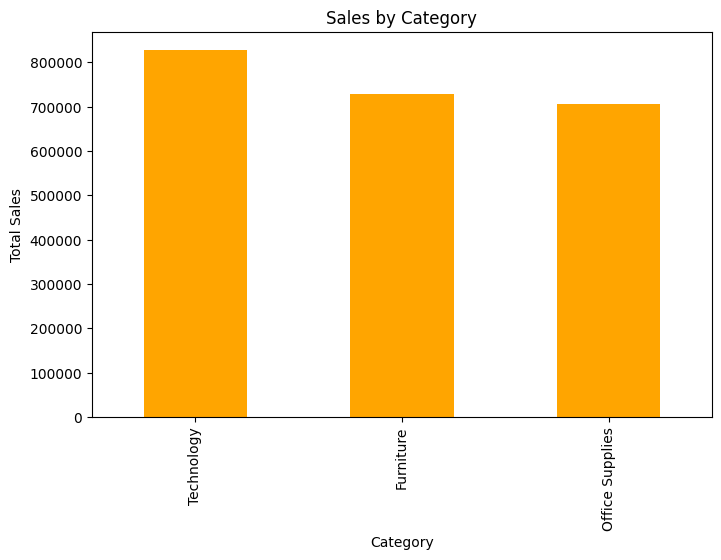

In [ ]:
plt.figure(figsize=(8,5))

category_sales.plot(kind='bar', color='orange')

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

In [ ]:
top_products = df.groupby('Product_Name')['Sales'].sum().sort_values(ascending=False).head(10)

print(top_products)

Product_Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24 Color                       18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


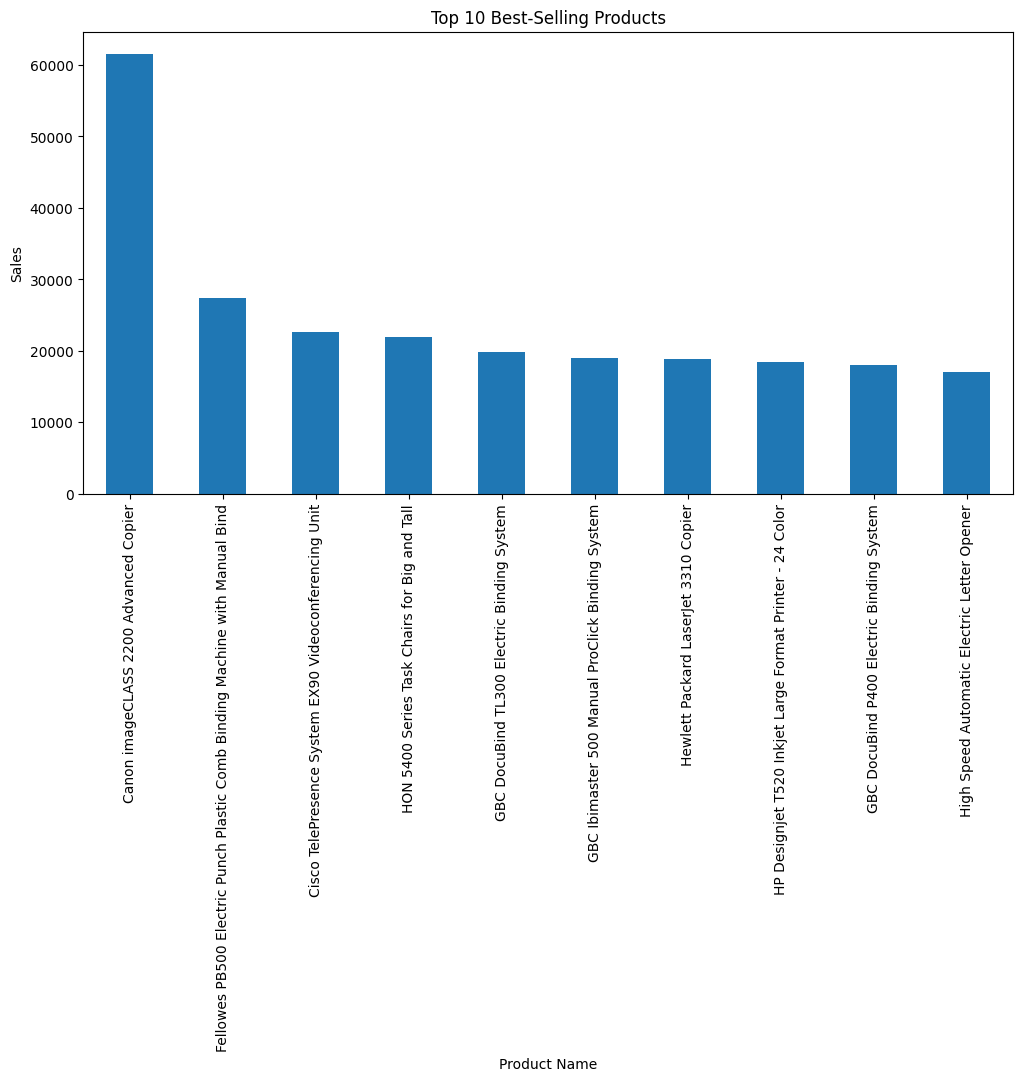

In [ ]:
plt.figure(figsize=(12,6))

top_products.plot(kind='bar')

plt.title("Top 10 Best-Selling Products")
plt.xlabel("Product Name")
plt.ylabel("Sales")

plt.show()

In [ ]:
lowest_products = df.groupby('Product_Name')['Sales'].sum().sort_values().head(10)

print(lowest_products)

Product_Name
Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac    1.624
Avery 5                                                             5.760
Xerox 20                                                            6.480
Grip Seal Envelopes                                                 7.072
Acme Serrated Blade Letter Opener                                   7.632
Avery Hi-Liter Pen Style Six-Color Fluorescent Set                  7.700
Avery Hi-Liter Comfort Grip Fluorescent Highlighter, Yellow Ink     7.800
Xerox 1989                                                          7.968
4009 Highlighters                                                   8.040
Stockwell Gold Paper Clips                                          8.096
Name: Sales, dtype: float64


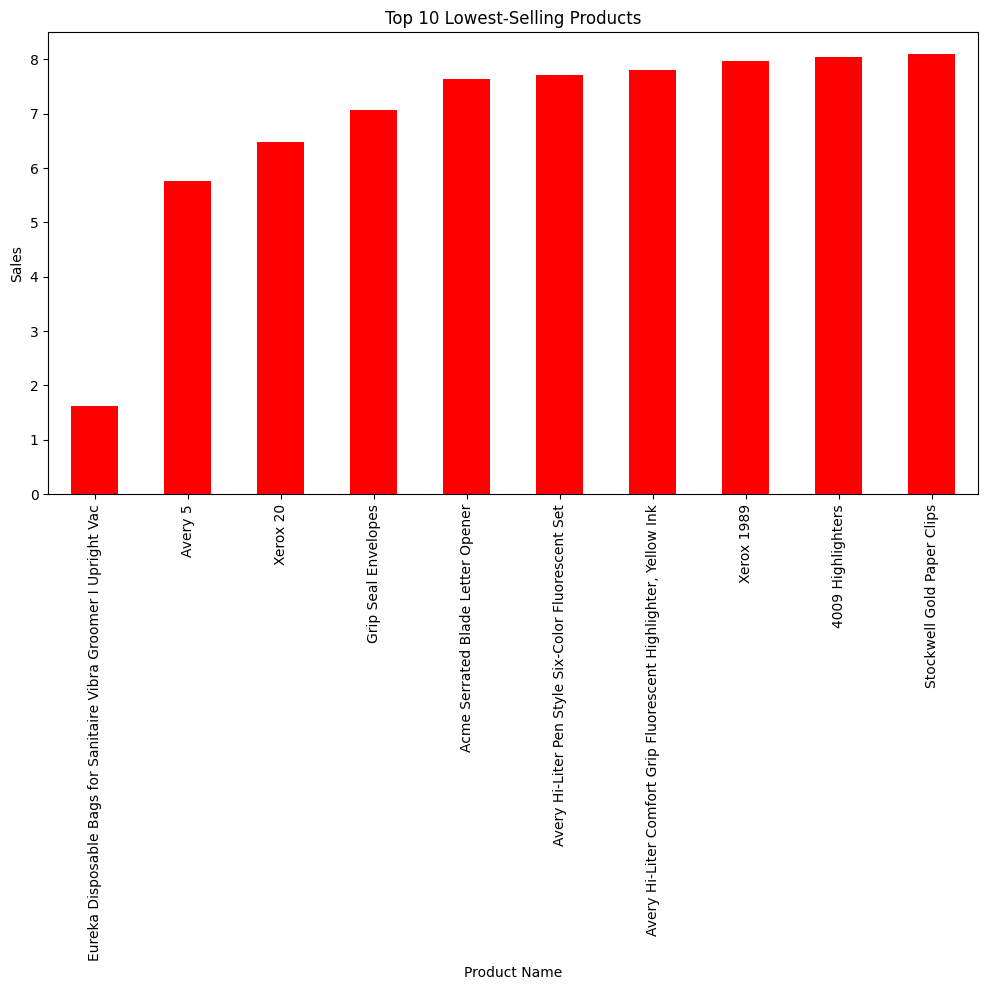

In [ ]:
plt.figure(figsize=(12,6))

lowest_products.plot(kind='bar', color='red')

plt.title("Top 10 Lowest-Selling Products")
plt.xlabel("Product Name")
plt.ylabel("Sales")

plt.show()

In [ ]:
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False)

print(state_sales.head(10))

State
California      446306.4635
New York        306361.1470
Texas           168572.5322
Washington      135206.8500
Pennsylvania    116276.6500
Florida          88436.5320
Illinois         79236.5170
Michigan         76136.0740
Ohio             75130.3500
Virginia         70636.7200
Name: Sales, dtype: float64


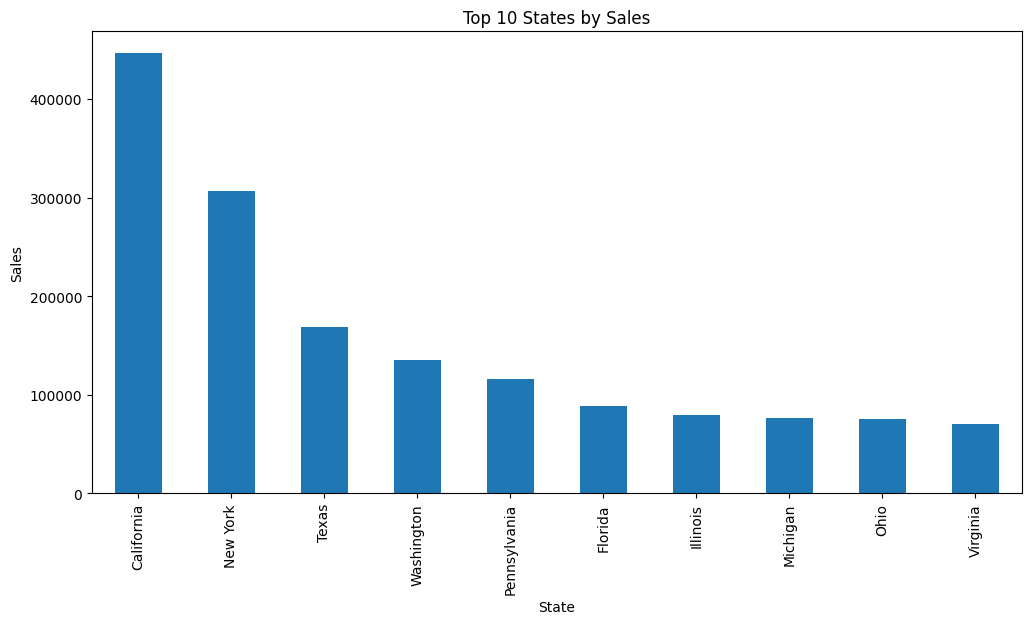

In [ ]:
plt.figure(figsize=(12,6))

state_sales.head(10).plot(kind='bar')

plt.title("Top 10 States by Sales")
plt.xlabel("State")
plt.ylabel("Sales")

plt.show()

In [ ]:
ship_mode_sales = df.groupby('Ship_Mode')['Sales'].sum()

print(ship_mode_sales)

Ship_Mode
First Class       3.455723e+05
Same Day          1.252190e+05
Second Class      4.499142e+05
Standard Class    1.340831e+06
Name: Sales, dtype: float64


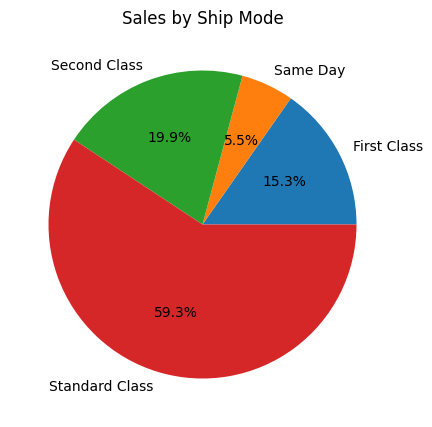

In [ ]:
plt.figure(figsize=(7,5))

ship_mode_sales.plot(kind='pie', autopct='%1.1f%%')

plt.title("Sales by Ship Mode")
plt.ylabel("")

plt.show()

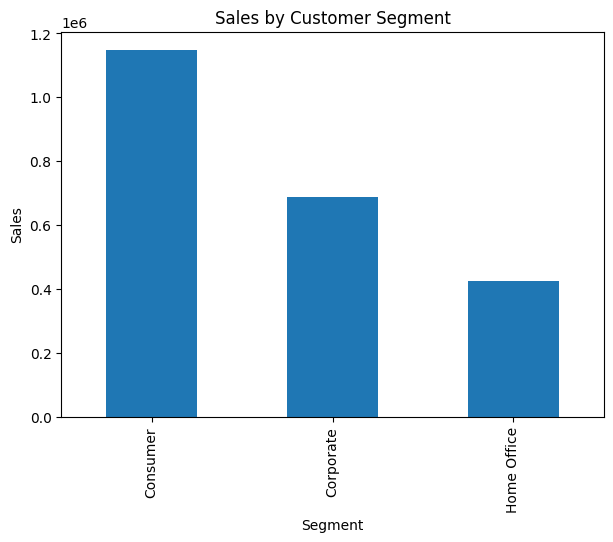

In [ ]:
segment_sales = df.groupby('Segment')['Sales'].sum()

plt.figure(figsize=(7,5))

segment_sales.plot(kind='bar')

plt.title("Sales by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Sales")

plt.show()

# Sales Performance Analysis

## Objective

Analyze sales performance across regions, categories, and time to identify sales trends, best and worst performing products, and provide business recommendations for Alfido Tech.


## Dataset

The dataset used for this project is **superstore_final_dataset.csv**.

It contains sales transactions, customer details, product information, shipping details, and regional sales data.

### Features

- Order ID
- Order Date
- Ship Date
- Ship Mode
- Customer ID
- Customer Name
- Segment
- Country
- City
- State
- Region
- Category
- Sub Category
- Product Name
- Sales


## Data Cleaning

The dataset was cleaned before analysis by performing the following steps:

- Checked for missing values.
- Removed duplicate records.
- Converted the Order Date column into datetime format.
- Verified the data types of all columns.


## KPI Analysis

Key Performance Indicators (KPIs) were calculated to evaluate business performance.

The KPIs include:

- Total Revenue
- Average Order Value

These metrics provide an overview of the company's sales performance.


## Sales Trend Analysis

Monthly sales trends were analyzed to understand business performance over time.

The analysis helps identify:

- Growth in sales over different months.
- Seasonal patterns in customer purchases.
- Peak and low sales periods.
- Business performance over time.



## Regional and Category Analysis

Sales performance was analyzed across different regions and product categories.

The analysis identified:

- Best-performing regions.
- Lowest-performing regions.
- Highest-selling product categories.
- Customer purchasing preferences across different locations.


## Product Performance

The sales performance of products was analyzed to identify the best-selling and lowest-selling products.

This analysis helps the business:

- Promote high-performing products.
- Improve marketing for low-performing products.
- Optimize inventory management.


## Key Findings

The sales performance analysis revealed the following insights:

1. Sales varied across different months, indicating seasonal trends in customer purchasing behavior.

2. Certain regions consistently generated higher sales than others, highlighting strong market performance.

3. Some product categories contributed significantly more revenue than others.

4. The top-selling products accounted for a major share of total sales, while a few products showed consistently low sales.

5. Customer segments and shipping modes influenced overall sales performance and purchasing patterns.


## Business Recommendations

Based on the analysis, the following recommendations are suggested for Alfido Tech:

1. Focus marketing efforts on high-performing regions to maximize sales growth.

2. Promote low-performing products through discounts, bundled offers, and targeted campaigns.

3. Increase inventory for top-selling products to prevent stock shortages.

4. Launch seasonal marketing campaigns during peak sales periods to increase revenue.

5. Use customer segmentation to provide personalized offers and improve customer satisfaction.


## Conclusion

This project analyzed sales performance using data cleaning, KPI calculations, and data visualization techniques.

The analysis identified sales trends, regional performance, product performance, and customer purchasing patterns. The insights and recommendations can help Alfido Tech improve sales strategies, optimize inventory management, and enhance customer satisfaction.

Overall, this project demonstrates how data analytics can support informed business decisions and drive organizational growth.
